In [1]:
import matplotlib.pyplot as plt

def calculate_average_accuracy(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    average_accuracies = []
    
    for i, line in enumerate(lines):
        values = list(map(float, line.split()))
        non_zero_values = values[:i+1]
        average_accuracy = sum(non_zero_values) / len(non_zero_values)
        average_accuracies.append(average_accuracy)
        #print(f"Row {i+1} average accuracy: {average_accuracy:.4f}")
    
    return average_accuracies

def plot_accuracies(file_paths):
    for file_path in file_paths:
        accuracies = calculate_average_accuracy(file_path)
        plt.plot(range(1, len(accuracies) + 1), accuracies, marker='o', label=file_path)
    
    plt.xlabel('Number of Tasks Learned')
    plt.ylabel('Average Accuracy')
    plt.title('Average Accuracy Across Tasks')
    plt.legend()
    plt.grid(True)
    plt.show()



In [1]:
dir1 = "./res/smnist/gvcl/kl_g"
dir2 = "./res/smnist/gvcl/re_g"

In [8]:
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, List
from scipy import stats



def calculate_average_accuracy(matrix: np.ndarray) -> np.ndarray:
    """
    Calculate average accuracy for a lower triangular matrix where
    each column is a task and each row represents training up to task i.
    Only considers the valid entries (lower triangle).
    """
    n = len(matrix)
    averages = []
    
    for i in range(n):
        valid_entries = matrix[i, :i+1]
        row_avg = np.mean(valid_entries)
        averages.append(row_avg)
    
    return np.array(averages)

def process_single_directory(directory_path: str) -> Tuple[np.ndarray, np.ndarray, List[float]]:
    """
    Process all .txt and .npy files in a directory and calculate statistics.
    Returns mean accuracy, standard deviation, and list of final accuracies.
    """
    file_extensions = ('*.txt', '*.npy')
    files = []
    for ext in file_extensions:
        files.extend(Path(directory_path).glob(ext))
    
    if not files:
        raise ValueError(f"No .txt or .npy files found in {directory_path}")
    
    all_averages = []
    final_accuracies = []
    
    for file_path in files:
        try:
            if file_path.suffix == '.npy':
                matrix = np.load(file_path)
            else:
                matrix = np.loadtxt(file_path)
            
            avg_accuracy = calculate_average_accuracy(matrix)
            all_averages.append(avg_accuracy)
            final_accuracies.append(np.mean(avg_accuracy))
            
        except Exception as e:
            print(f"Error processing {file_path}: {str(e)}")
            continue
    
    all_averages = np.array(all_averages)
    mean_accuracy = np.mean(all_averages, axis=0)
    std_accuracy = np.std(all_averages, axis=0)
    
    return mean_accuracy, std_accuracy, final_accuracies

def compare_directories(dir1: str, dir2: str, label1: str = "Directory 1", label2: str = "Directory 2"):
    """
    Compare results between two directories and create visualizations.
    """
    # Process both directories
    mean1, std1, finals1 = process_single_directory(dir1)
    mean2, std2, finals2 = process_single_directory(dir2)
    
    # Print statistical summary
    print("\nStatistical Summary:")
    print("=" * 50)
    print(f"\n{label1}:")
    print(f"Average accuracy: {np.mean(mean1):.4f} ± {np.mean(std1):.4f}")
    print(f"Final average accuracy: {mean1[-1]:.4f} ± {std1[-1]:.4f}")
    print(f"Number of files: {len(finals1)}")
    
    print(f"\n{label2}:")
    print(f"Average accuracy: {np.mean(mean2):.4f} ± {np.mean(std2):.4f}")
    print(f"Final average accuracy: {mean2[-1]:.4f} ± {std2[-1]:.4f}")
    print(f"Number of files: {len(finals2)}")
    
    # Calculate statistical significance
    t_stat, p_value = stats.ttest_ind(finals1, finals2)
    print(f"\nStatistical comparison:")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value: {p_value:.4f}")

    # Create comparison visualization
    plt.figure(figsize=(12, 6))
    tasks = np.arange(1, len(mean1) + 1)
    
    # Plot first directory results
    plt.plot(tasks, mean1, 'b-', label=label1)
    plt.fill_between(tasks, mean1 - std1, mean1 + std1, 
                    alpha=0.2, color='b')
    
    # Plot second directory results
    plt.plot(tasks, mean2, 'r-', label=label2)
    plt.fill_between(tasks, mean2 - std2, mean2 + std2, 
                    alpha=0.2, color='r')
    
    plt.xlabel('Number of Tasks Trained')
    plt.ylabel('Average Accuracy')
    plt.title('Average accuracy on CIFAR10-100')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    
    # Save comparison plot
    output_path = Path(dir1).parent / 'accuracy_comparison_cifar_gvcl_new.png'
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    plt.close()
    
    # Create box plot of final accuracies
    plt.figure(figsize=(8, 6))
    plt.boxplot([finals1, finals2], labels=[label1, label2])
    plt.ylabel('Final Average Accuracy')
    plt.title('Distribution of Final Accuracies')
    
    # Save box plot
    output_path = Path(dir1).parent / 'final_accuracy_distribution.png'
    plt.savefig(output_path, bbox_inches='tight', dpi=300)
    plt.close()


if __name__ == "__main__":
    # Example usage
    dir1 = "./res/cifar/gvcl/kl_g"
    dir2 = "./res/cifar/gvcl/re_g"
    compare_directories(dir1, dir2, "KL regularization of gaussians", "Renyi regularization of gaussians")


Statistical Summary:

KL regularization of gaussians:
Average accuracy: 0.7438 ± 0.0051
Final average accuracy: 0.7236 ± 0.0049
Number of files: 5

Renyi regularization of gaussians:
Average accuracy: 0.7365 ± 0.0043
Final average accuracy: 0.7136 ± 0.0032
Number of files: 5

Statistical comparison:
t-statistic: 6.5833
p-value: 0.0002


RuntimeError: Failed to process string with tex because latex could not be found

RuntimeError: Failed to process string with tex because latex could not be found

<Figure size 3600x1800 with 1 Axes>

## FWT BWT and average accuracy

In [12]:
import numpy as np

def calculate_average_accuracy(R_matrix: np.ndarray) -> np.ndarray:
    """
    Calculate average accuracy for a lower triangular matrix where 
    each column is a task and each row represents training up to task i.
    Only considers the valid entries (lower triangle).
    """
    n = R_matrix.shape[0]
    averages = []
    for i in range(n):
        valid_entries = R_matrix[i, :i+1]
        row_avg = np.mean(valid_entries)
        averages.append(row_avg)
    return np.array(averages)

def calculate_BWT(R_matrix: np.ndarray) -> np.ndarray:
    """
    Calculate average accuracy for a lower triangular matrix where 
    each column is a task and each row represents training up to task i.
    Only considers the valid entries (lower triangle).
    """
    n = R_matrix.shape[0]
    averages = []
    for i in range(n):
        valid_entries = R_matrix[i, :i+1]
        row_avg = np.mean(valid_entries)
        averages.append(row_avg)
    return np.array(averages)

def forward_transfer(R_matrix: np.ndarray, T: int) -> float:
    """
    Calculate Forward Transfer (FWT).
    Only considers the valid entries (lower triangle).
    """
    fwt = (1 / T) * sum(R_matrix[i, :i+1].mean() - R_matrix[i, i] for i in range(T))
    return fwt

def backward_transfer(R_matrix: np.ndarray, T: int) -> float:
    """
    Calculate Backward Transfer (BWT). 
    Only considers the valid entries (lower triangle).
    """
    bwt = (1 / T) * sum(R_matrix[i, :i+1].mean() - R_matrix[i, i] for i in range(T))
    return bwt

class TransferMetrics:
    def __init__(self, R_matrix: np.ndarray):
        self.R_matrix = R_matrix
        self.T = R_matrix.shape[0]
    
    def calculate_average_accuracy(self) -> np.ndarray:
        return calculate_average_accuracy(self.R_matrix)
    
    def calculate_forward_transfer(self) -> float:
        return forward_transfer(self.R_matrix, self.T)
    
    def calculate_backward_transfer(self) -> float:
        return backward_transfer(self.R_matrix, self.T)

In [13]:
R_matrix = np.array([[0.9, 0.8, 0.7], 
                     [0.0, 0.85, 0.75],
                     [0.0, 0.0, 0.8]])

metrics = TransferMetrics(R_matrix)
avg_accuracy = metrics.calculate_average_accuracy()
fwt = metrics.calculate_forward_transfer()
bwt = metrics.calculate_backward_transfer()

In [14]:
R_matrix, avg_accuracy, fwt, bwt    

(array([[0.9 , 0.8 , 0.7 ],
        [0.  , 0.85, 0.75],
        [0.  , 0.  , 0.8 ]]),
 array([0.9       , 0.425     , 0.26666667]),
 np.float64(-0.3194444444444445),
 np.float64(-0.3194444444444445))

In [27]:
import os

def create_path(base_dir, experiment, approach, regularizer):
    path = os.path.join(base_dir, experiment, approach, regularizer)
    return path

# Example usage
base_dir = '../res'
experiment = 'smnist'
approach = 'gvcl'
regularizer = 'kl_g'

path = create_path(base_dir, experiment, approach, regularizer)
print(path)

../res/smnist/gvcl/kl_g


In [ ]:
get a list of all

In [34]:
import os

def get_all_files(path):
    try:
        files = os.listdir(path)
        return [os.path.join(path, file) for file in files if os.path.isfile(os.path.join(path, file))]
    except FileNotFoundError:
        print(f"The directory {path} does not exist.")
        return []

# Example usage
path = './res/smnist/gvcl/kl_g'
files = get_all_files(path)
print(files)

['./res/smnist/gvcl/kl_g/smnist_gvcl_kl_g_1.01_21.txt', './res/smnist/gvcl/kl_g/smnist_gvcl_kl_g_23.txt', './res/smnist/gvcl/kl_g/smnist_gvcl_kl_g_61.txt', './res/smnist/gvcl/kl_g/smnist_gvcl_kl_g_47.txt', './res/smnist/gvcl/kl_g/smnist_gvcl_kl_g_93.txt', './res/smnist/gvcl/kl_g/smnist_gvcl_kl_g_1.01_4.txt', './res/smnist/gvcl/kl_g/smnist_gvcl_kl_g_1.01_42.txt', './res/smnist/gvcl/kl_g/smnist_gvcl_kl_g_1.01_80.txt', './res/smnist/gvcl/kl_g/smnist_gvcl_kl_g_1.01_67.txt', './res/smnist/gvcl/kl_g/smnist_gvcl_kl_g_1.txt']


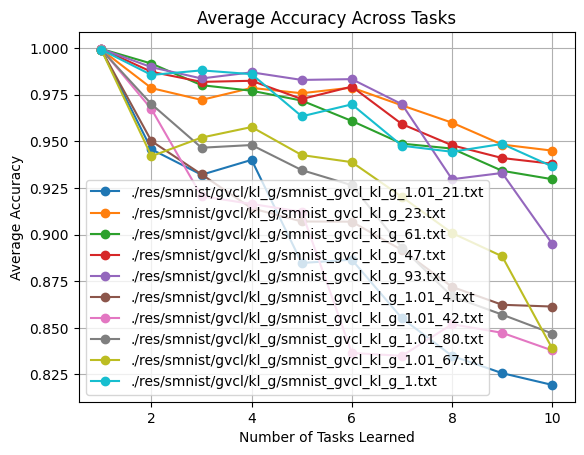

In [35]:
# List of result files
result_files_smnist = [
    os.path.join(path, ),
    '../res/smnist_hat_0.txt',
    '../res/smnist_vcrenyi_3.txt',
    '../res/smnist_gvclf(bug)_0.txt',
    '../res/smnist_gvclf_14.txt',
    '../res/smnist_vcrenyif_3.txt',
]

# Plot the accuracies for each result file
plot_accuracies(files)

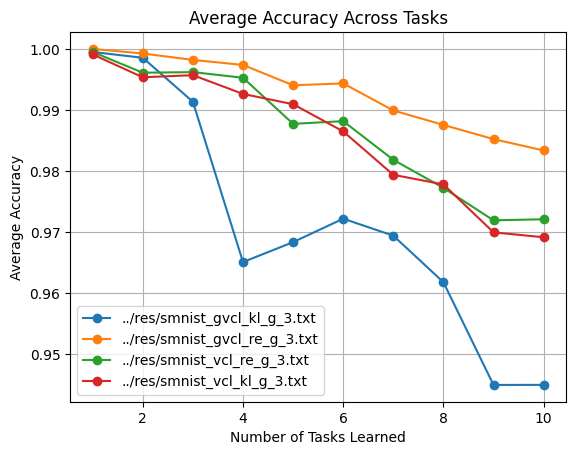

In [4]:
# List of result files
result_files_smnist = [
    '../res/smnist_gvcl_kl_g_3.txt',
    '../res/smnist_gvcl_re_g_3.txt',
    '../res/smnist_vcl_re_g_3.txt',
    '../res/smnist_vcl_kl_g_3.txt',
]

# Plot the accuracies for each result file
plot_accuracies(result_files_smnist)

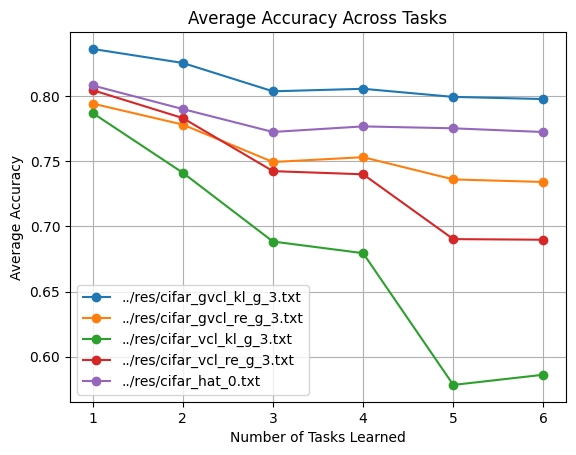

In [2]:
# List of result files on cifar
result_files_cifar = [
    '../res/cifar_gvcl_kl_g_3.txt',
    '../res/cifar_gvcl_re_g_3.txt',
    '../res/cifar_vcl_kl_g_3.txt',
    '../res/cifar_vcl_re_g_3.txt',
    '../res/cifar_hat_0.txt'
]

# Plot the accuracies for each result file
plot_accuracies(result_files_cifar)